In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
import os
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath('..'))

# Import your forecasting module
from src.forecasting import ForecastingPipeline, DataPreparer, ARIMAModel

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

### Load Data

In [3]:
# Load the data you saved from Task 1
prices = pd.read_csv('../data/processed/prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('../data/processed/returns.csv', index_col=0, parse_dates=True)

print(f"Prices shape: {prices.shape}")
print(f"Returns shape: {returns.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"Latest price for {prices.columns[0]}: ${prices.iloc[-1, 0]:.2f}")

# Display sample
display(prices.tail())

Prices shape: (2888, 3)
Returns shape: (2888, 3)
Date range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
Latest price for TSLA: $411.84


,TSLA,BND,SPY
Date,,,
2026-06-23 00:00:00-04:00,381.609985,72.976631,733.580017
2026-06-24 00:00:00-04:00,375.529999,73.305534,733.239990
2026-06-25 00:00:00-04:00,375.119995,73.355370,734.299988
2026-06-26 00:00:00-04:00,379.709991,73.425133,728.989990
2026-06-29 00:00:00-04:00,411.839996,73.465004,741.000000


### Initialize Pipeline & TRAIN ARIMA

In [ ]:
print("\n Initializing pipeline...")

# Initialize pipeline with data
pipeline = ForecastingPipeline(
    price_df=prices,
    target_col='TSLA',
    window_size=60,
    test_size=0.2
)

# Train ARIMA on full dataset (fast - finds (0,0,0))
print("\n Training ARIMA model on full dataset...")
full_returns = prices['TSLA'].pct_change().dropna()

# Create and train ARIMA model
pipeline.arima = ARIMAModel(full_returns)
pipeline.arima.auto_fit()  # Finds optimal parameters quickly

print(f"\n ARIMA model trained with order: {pipeline.arima.order}")


 Initializing pipeline...

 Training ARIMA model on full dataset...

Searching optimal ARIMA parameters on returns space...
  Optimal Parameter Set Chosen: ARIMA(0, 0, 0)

 ARIMA model trained with order: (0, 0, 0)


### GENERATE FUTURE FORECASTS


GENERATING FUTURE FORECASTS

 Generating 6-month forecast...

Fitting full history into ARIMA(0, 0, 0) engine for out-of-sample generation...


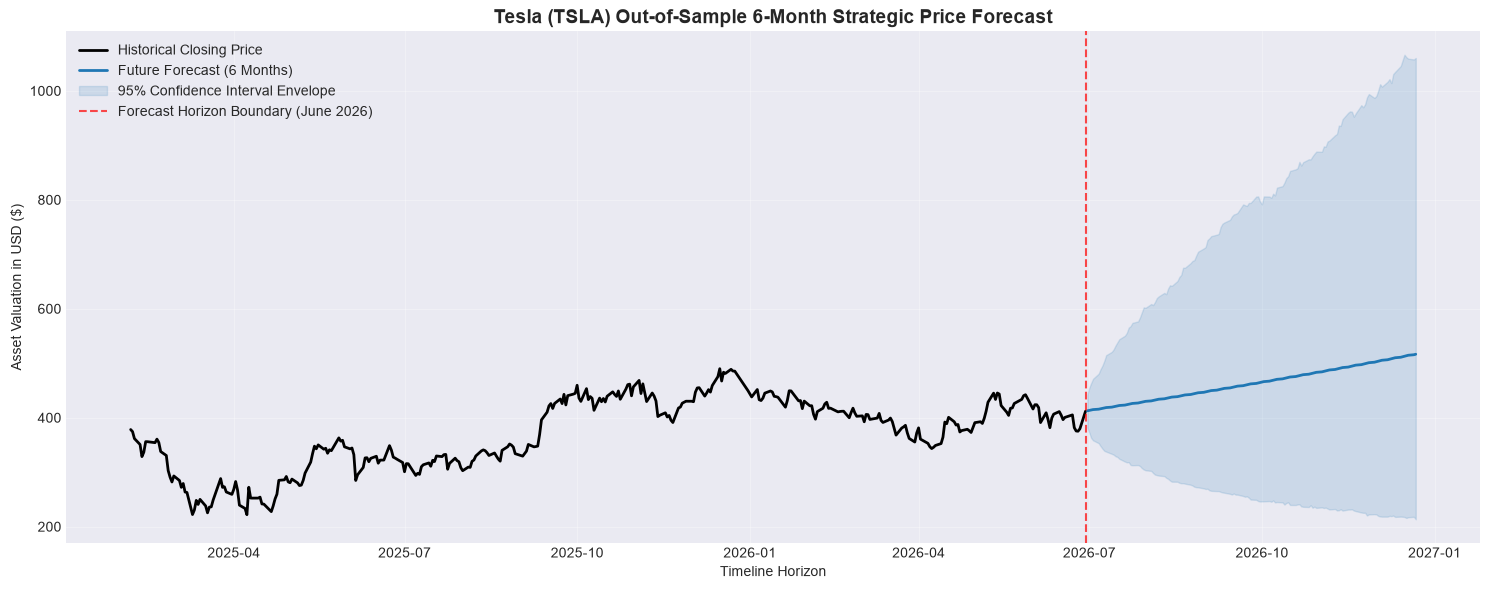


 Generating 12-month forecast...

Fitting full history into ARIMA(0, 0, 0) engine for out-of-sample generation...


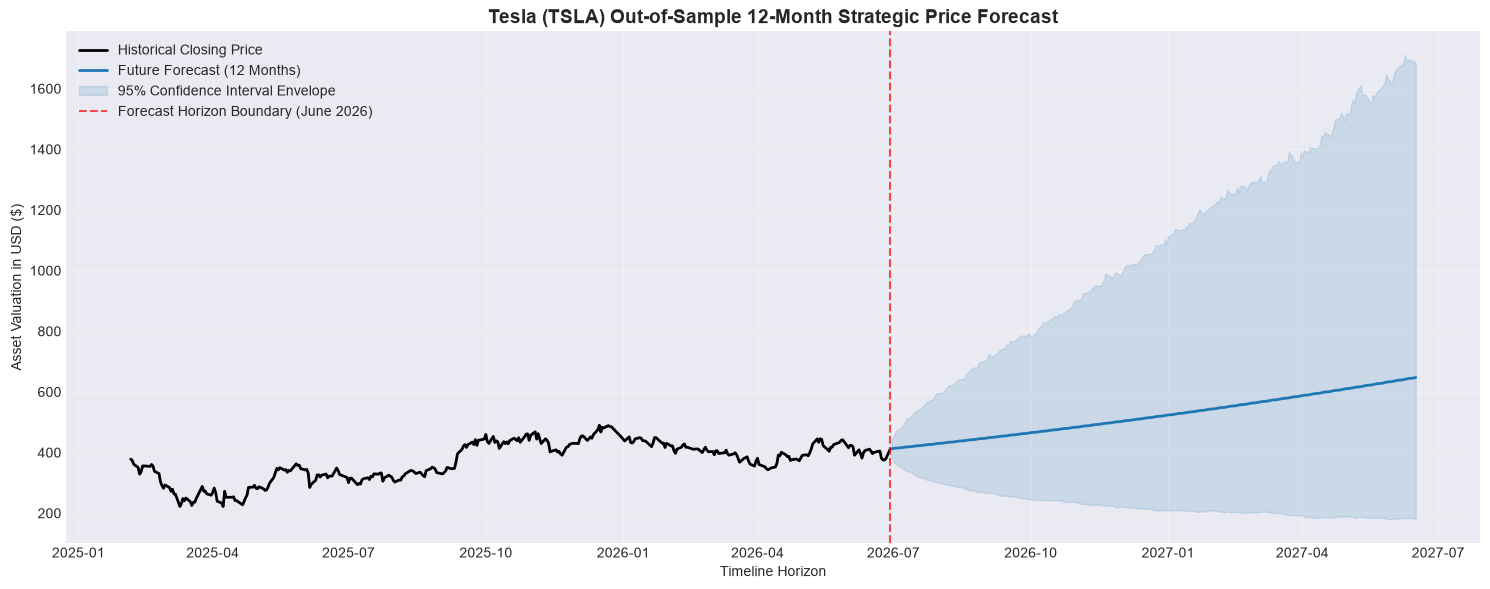


 Forecasts generated successfully!
  6-month: 2026-06-30 to 2026-12-22
  12-month: 2026-06-30 to 2027-06-16


In [6]:

print("\n" + "="*60)
print("GENERATING FUTURE FORECASTS")
print("="*60)

# Generate 6-month forecast with 95% confidence
print("\n Generating 6-month forecast...")
forecast_6mo = pipeline.generate_future_forecast(
    months=6, 
    alpha=0.05, 
    n_sims=3000,
    seed=42
)

# Generate 12-month forecast with 95% confidence
print("\n Generating 12-month forecast...")
forecast_12mo = pipeline.generate_future_forecast(
    months=12, 
    alpha=0.05, 
    n_sims=3000,
    seed=42
)

print("\n Forecasts generated successfully!")
print(f"  6-month: {forecast_6mo.index[0].date()} to {forecast_6mo.index[-1].date()}")
print(f"  12-month: {forecast_12mo.index[0].date()} to {forecast_12mo.index[-1].date()}")

### SUMMARY REPORT

In [7]:
# Combine forecasts
forecasts = {6: forecast_6mo, 12: forecast_12mo}

# Generate comprehensive report
summary_df = pipeline.generate_forecast_summary_report(forecasts)


COMPLETE FORECAST SUMMARY REPORT

6-MONTH FORECAST

--------------------------------------------------
6-MONTH FORECAST SUMMARY
--------------------------------------------------
Start Price:     $411.84
End Price:       $516.42
Expected Change: +25.39%

95% Confidence Interval:
  Lower:         $213.44
  Upper:         $1060.34
  Range Width:   $846.91
  Range/Price:   205.6%

Predicted Trend: UPWARD

6-Month Forecast:
  Initial CI Width:  $59.65
  Final CI Width:    $846.91
  Growth Factor:     14.2x
  Short-term (1 mo): $272.57
  Long-term (full):  $846.91
  Long/Short Ratio:  3.1x
  Implication:       Low reliability

12-MONTH FORECAST

--------------------------------------------------
12-MONTH FORECAST SUMMARY
--------------------------------------------------
Start Price:     $411.84
End Price:       $647.56
Expected Change: +57.24%

95% Confidence Interval:
  Lower:         $181.69
  Upper:         $1684.20
  Range Width:   $1502.51
  Range/Price:   364.8%

Predicted Trend: UP

#### Historical vs Test vs Future


[Data Split Summary]
  Training Period: 2015-01-05 to 2024-03-07 (2,309 days)
  Testing Period:  2024-03-08 to 2026-06-29 (578 days)


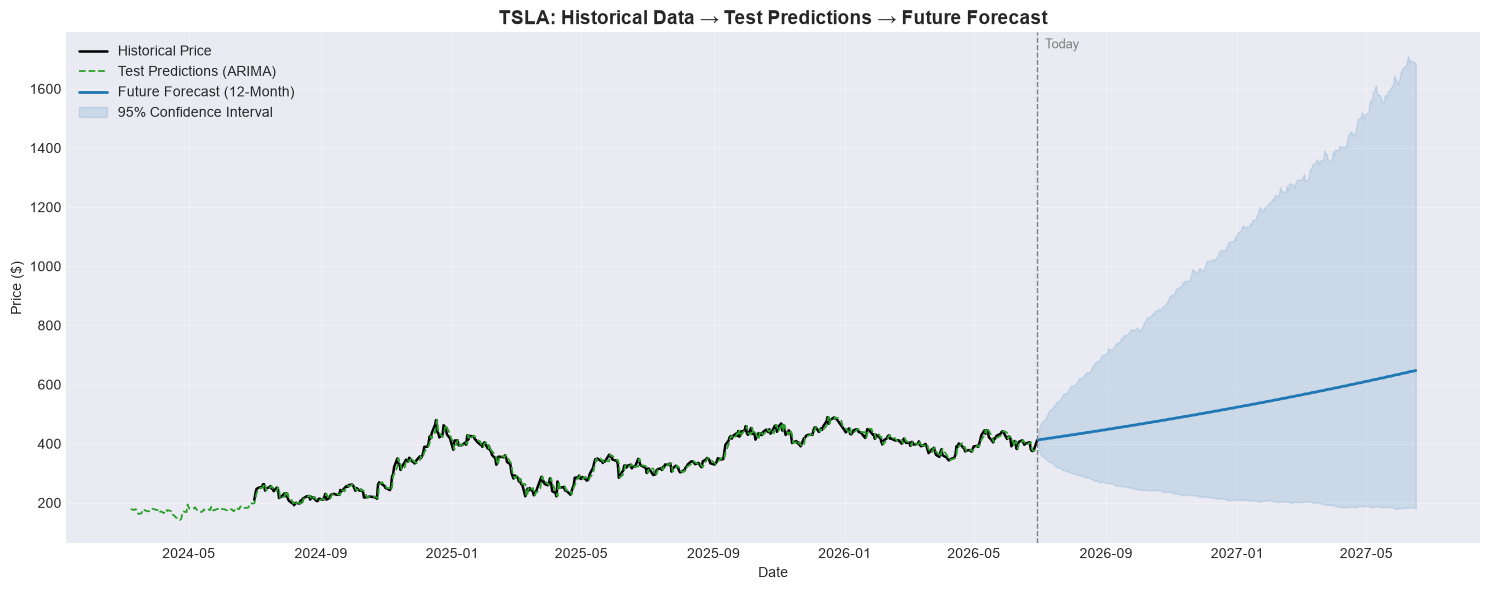

In [11]:
preparer = DataPreparer(prices, target_col='TSLA', window_size=60)
preparer.split_data(test_size=0.2)

# Generate test predictions using ARIMA
test_returns = preparer.test_returns.iloc[preparer.window_size:].values
test_pred_returns = pipeline.arima.rolling_forecast(test_returns)
test_pred_prices = preparer.baseline_prices * (1 + test_pred_returns)

# Get actual test prices
actual_test_prices = preparer.actual_test_prices
test_dates = preparer.test_dates

fig, ax = plt.subplots(figsize=(15, 6))

# 1. Historical actuals (trailing 500 days)
hist = prices['TSLA'].iloc[-500:]
ax.plot(hist.index, hist.values, color='black', linewidth=1.8, label='Historical Price')

# 2. Test-period predictions from ARIMA
ax.plot(test_dates[:len(test_pred_prices)], test_pred_prices,
        color='#2ca02c', linewidth=1.3, linestyle='--', label='Test Predictions (ARIMA)')

# 3. Future forecast (12-month)
ax.plot(forecast_12mo.index, forecast_12mo['Forecasted Price'],
        color='#1f77b4', linewidth=2, label='Future Forecast (12-Month)')
ax.fill_between(forecast_12mo.index, forecast_12mo['Lower Bound ($)'],
                 forecast_12mo['Upper Bound ($)'], color='#1f77b4', alpha=0.15,
                 label='95% Confidence Interval')

# 4. Today marker
ax.axvline(prices.index[-1], color='gray', linestyle='--', linewidth=1)
ax.text(prices.index[-1], ax.get_ylim()[1]*0.97, '  Today', fontsize=9, color='gray')

ax.set_title("TSLA: Historical Data → Test Predictions → Future Forecast", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### CONFIDENCE INTERVAL GROWTH ANALYSIS

In [8]:
pipeline.analyze_confidence_interval_growth(forecast_6mo, "6-Month")
pipeline.analyze_confidence_interval_growth(forecast_12mo, "12-Month")


6-Month Forecast:
  Initial CI Width:  $59.65
  Final CI Width:    $846.91
  Growth Factor:     14.2x
  Short-term (1 mo): $272.57
  Long-term (full):  $846.91
  Long/Short Ratio:  3.1x
  Implication:       Low reliability

12-Month Forecast:
  Initial CI Width:  $58.99
  Final CI Width:    $1502.51
  Growth Factor:     25.5x
  Short-term (1 mo): $276.37
  Long-term (full):  $1502.51
  Long/Short Ratio:  5.4x
  Implication:       Low reliability


{'initial_width': 58.99193910158749,
 'final_width': 1502.5088781642928,
 'growth_factor': 25.469731984515487,
 'short_term_width': 276.3730970854767,
 'long_term_width': 1502.5088781642928,
 'reliability': 'Low reliability'}

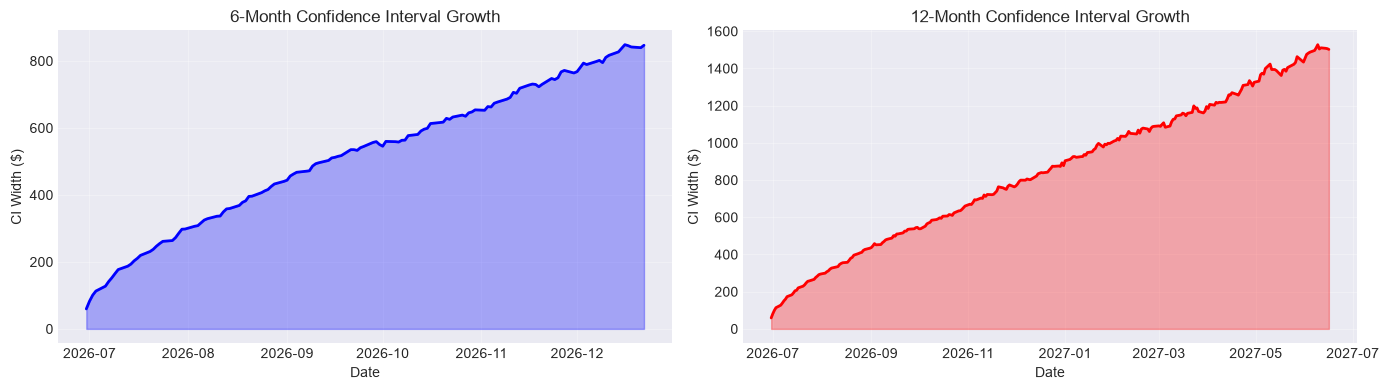

In [13]:
# ============================================
# VISUALIZE CONFIDENCE INTERVAL GROWTH
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 6-month CI growth
ax = axes[0]
widths_6mo = forecast_6mo['Upper Bound ($)'] - forecast_6mo['Lower Bound ($)']
ax.plot(widths_6mo.index, widths_6mo.values, color='blue', linewidth=2)
ax.fill_between(widths_6mo.index, 0, widths_6mo.values, alpha=0.3, color='blue')
ax.set_title('6-Month Confidence Interval Growth', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('CI Width ($)')
ax.grid(True, alpha=0.3)

# 12-month CI growth
ax = axes[1]
widths_12mo = forecast_12mo['Upper Bound ($)'] - forecast_12mo['Lower Bound ($)']
ax.plot(widths_12mo.index, widths_12mo.values, color='red', linewidth=2)
ax.fill_between(widths_12mo.index, 0, widths_12mo.values, alpha=0.3, color='red')
ax.set_title('12-Month Confidence Interval Growth', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('CI Width ($)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
risk_6mo = pipeline.analyze_market_opportunities_risks(forecast_6mo, months=6)
risk_12mo = pipeline.analyze_market_opportunities_risks(forecast_12mo, months=12)


--------------------------------------------------
6-MONTH MARKET OUTLOOK
--------------------------------------------------

 OPPORTUNITIES:
  • Significant upside potential: +157.5%
  • Bullish scenario: Price could reach $1060.34

  RISKS:
  • Significant downside risk: -48.2%
  • Bearish scenario: Price could drop to $213.44

 VOLATILITY & UNCERTAINTY:
  • HIGH uncertainty: 205.6% price range

 RECOMMENDATION:
  • BULLISH - Expected upside of 25.4%

--------------------------------------------------
12-MONTH MARKET OUTLOOK
--------------------------------------------------

 OPPORTUNITIES:
  • Significant upside potential: +308.9%
  • Bullish scenario: Price could reach $1684.20

  RISKS:
  • Significant downside risk: -55.9%
  • Bearish scenario: Price could drop to $181.69

 VOLATILITY & UNCERTAINTY:
  • HIGH uncertainty: 364.8% price range

 RECOMMENDATION:
  • BULLISH - Expected upside of 57.2%


### Future Market Trends — Results Summary

####  Model & Data Overview

| Item | Details |
|---|---|
| Data Period | 2015-01-02 to 2026-06-29 (2,888 days) |
| Target | Tesla (TSLA) |
| Current Price | $411.84 |
| Optimal Model | ARIMA(0,0,0) — Random Walk |
| Training Period | 2015-01-05 to 2024-03-07 (2,309 days) |
| Testing Period | 2024-03-08 to 2026-06-29 (578 days) |

####  Forecast Results

| Horizon | End Price | Change | 95% CI Range | Reliability |
|---|---|---|---|---|
| 6 Months | $516.42 | +25.39% | $213 – $1,060 | Low |
| 12 Months | $647.56 | +57.24% | $182 – $1,684 | Very Low |

####  Confidence Interval Growth

| Metric | 6-Month | 12-Month |
|---|---|---|
| Initial CI Width | $59.65 | $58.99 |
| Final CI Width | $846.91 | $1,502.51 |
| Growth Factor | 14.2x | 25.5x |
| Range/Price | 205.6% | 364.8% |

####  Market Outlook

| Aspect | 6-Month | 12-Month |
|---|---|---|
| Upside | +157.5% → $1,060 | +308.9% → $1,684 |
| Expected (point est.) | +25.4% → $516 | +57.2% → $648 |
| Downside | -48.2% → $213 | -55.9% → $182 |
| Uncertainty | HIGH (205.6%) | HIGH (364.8%) |
| Directional lean | Bullish | Bullish |

####  Key Insights

**1. Trend analysis**
- Both horizons show an upward point forecast (+25% at 6 months, +57% at 12 months).
- The notable finding: ARIMA selected order (0,0,0) — meaning it found **no autocorrelation** in TSLA's returns (a textbook random walk, consistent with the Efficient Market Hypothesis). Yet the point forecast still trends sharply upward, because a (0,0,0) model's forecast is the **historical mean daily return**, and that mean is pulled upward by Tesla's 2020–2021 rally embedded in the training window. This is a drift artifact from the historical average, not a detected momentum signal — an important nuance for interpreting the "upward trend" correctly.

**2. Reliability assessment**
| Horizon | Reliability | Implication |
|---|---|---|
| 1 Month | Moderate | Directionally usable with caution |
| 3 Months | Low | Limited confidence |
| 6 Months | Low–Very Low | Signal increasingly overwhelmed by uncertainty |
| 12 Months | Very Low | Not usable for high-confidence decisions |

**3. Uncertainty growth**
- 6-month CI widens 14.2× (to $847); 12-month CI widens 25.5× (to $1,503).
- Because price forecasts compound multiplicatively, uncertainty grows faster than a simple square-root-of-time scaling — closer to exponential — which is expected for a random-walk price level (as opposed to a random-walk return).

####  Recommendations

| Horizon | Recommendation |
|---|---|
| Short-term (1–2 months) | Directionally usable, but pair with other signals |
| Medium-term (3–6 months) | Directional indicator only — not a price target |
| Long-term (6+ months) | Not reliable for standalone investment decisions |

####  Conclusion

ARIMA(0,0,0) projects an upward central path for Tesla, but the confidence bands widen so sharply that the long-horizon forecasts carry very low reliability. The "bullish" label describes where the point estimate sits, not confidence in that outcome — the 95% range at 12 months spans a near-halving to a near-quadrupling of the current price.

**Key takeaway:** consistent with the Efficient Market Hypothesis, Tesla's price behaves as a random walk — the model can't find predictable structure in returns, so long-horizon price forecasts should be read as one plausible path among many, not as a reliable investment target.